In [5]:
import pandas as pd

df = pd.read_csv('../Data/preprocessed_dataset.csv')
df.head()

,Komentar,Komentar_bersih,normal_teks,Label,Label_Validator
0,@𝙈𝙖𝙥𝙡𝙖𝙮𝟕𝟖𝟗 🖤 withdraw never die🖤,mention_maplay789 emoji_black_heart withdraw n...,mention_maplay789 emoji_black_heart penarikan ...,1,1.0
1,@𝙈𝙖𝙥𝙡𝙖𝙮𝟕𝟖𝟗 💚congratulations💚,mention_maplay789 emoji_green_heart congratula...,mention_maplay789 emoji_green_heart selamat em...,1,1.0
2,@macanhoki789 💛💜 only one brother💜💛,mention_macanhoki789 emoji_yellow_heart emoji_...,mention_macanhoki789 emoji_yellow_heart emoji_...,1,1.0
3,@macanhoki789 💛💜 give up brother💜💛,mention_macanhoki789 emoji_yellow_heart emoji_...,mention_macanhoki789 emoji_yellow_heart emoji_...,1,1.0
4,pulen pulen,pulen pulen,pulen pulen,5,5.0


In [4]:
df.insert(0, 'Indeks', range(1, len(df) + 1))
df.to_csv('data/dataset_with_index.csv', index=False)

In [6]:
df = pd.read_csv('data/dataset_with_index.csv')
df.head()
df.dtypes

,Indeks,Komentar,Komentar_bersih,normal_teks,Label,Label_Validator
0,1,@𝙈𝙖𝙥𝙡𝙖𝙮𝟕𝟖𝟗 🖤 withdraw never die🖤,mention_maplay789 emoji_black_heart withdraw n...,mention_maplay789 emoji_black_heart penarikan ...,1,1.0
1,2,@𝙈𝙖𝙥𝙡𝙖𝙮𝟕𝟖𝟗 💚congratulations💚,mention_maplay789 emoji_green_heart congratula...,mention_maplay789 emoji_green_heart selamat em...,1,1.0
2,3,@macanhoki789 💛💜 only one brother💜💛,mention_macanhoki789 emoji_yellow_heart emoji_...,mention_macanhoki789 emoji_yellow_heart emoji_...,1,1.0
3,4,@macanhoki789 💛💜 give up brother💜💛,mention_macanhoki789 emoji_yellow_heart emoji_...,mention_macanhoki789 emoji_yellow_heart emoji_...,1,1.0
4,5,pulen pulen,pulen pulen,pulen pulen,5,5.0


In [10]:
df['Label_Validator'] = df['Label_Validator'].astype('int64')
df.dtypes
df.head()

,Indeks,Komentar,Komentar_bersih,normal_teks,Label,Label_Validator
0,1,@𝙈𝙖𝙥𝙡𝙖𝙮𝟕𝟖𝟗 🖤 withdraw never die🖤,mention_maplay789 emoji_black_heart withdraw n...,mention_maplay789 emoji_black_heart penarikan ...,1,1
1,2,@𝙈𝙖𝙥𝙡𝙖𝙮𝟕𝟖𝟗 💚congratulations💚,mention_maplay789 emoji_green_heart congratula...,mention_maplay789 emoji_green_heart selamat em...,1,1
2,3,@macanhoki789 💛💜 only one brother💜💛,mention_macanhoki789 emoji_yellow_heart emoji_...,mention_macanhoki789 emoji_yellow_heart emoji_...,1,1
3,4,@macanhoki789 💛💜 give up brother💜💛,mention_macanhoki789 emoji_yellow_heart emoji_...,mention_macanhoki789 emoji_yellow_heart emoji_...,1,1
4,5,pulen pulen,pulen pulen,pulen pulen,5,5


In [11]:
print("Shape dataset:", df.shape)
print("Kolom:", df.columns.tolist())
print("Missing values:\n", df.isnull().sum())

Shape dataset: (68797, 6)
Kolom: ['Indeks', 'Komentar', 'Komentar_bersih', 'normal_teks', 'Label', 'Label_Validator']
Missing values:
 Indeks             0
Komentar           0
Komentar_bersih    0
normal_teks        1
Label              0
Label_Validator    0
dtype: int64


In [12]:
# =====================
# 2. Distribusi Label
# =====================
print("\nDistribusi Label_Validator:")
print(df["Label_Validator"].value_counts())

print("\nDistribusi Label:")
print(df["Label"].value_counts())


Distribusi Label_Validator:
Label_Validator
0    51481
3     5365
1     4095
4     3780
5     3726
2      350
Name: count, dtype: int64

Distribusi Label:
Label
0    51416
3     5178
1     4132
4     4080
5     3665
2      326
Name: count, dtype: int64


C:\Users\Asus\AppData\Local\Temp\ipykernel_22456\3713473143.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette='Set2', ax=axs[1])


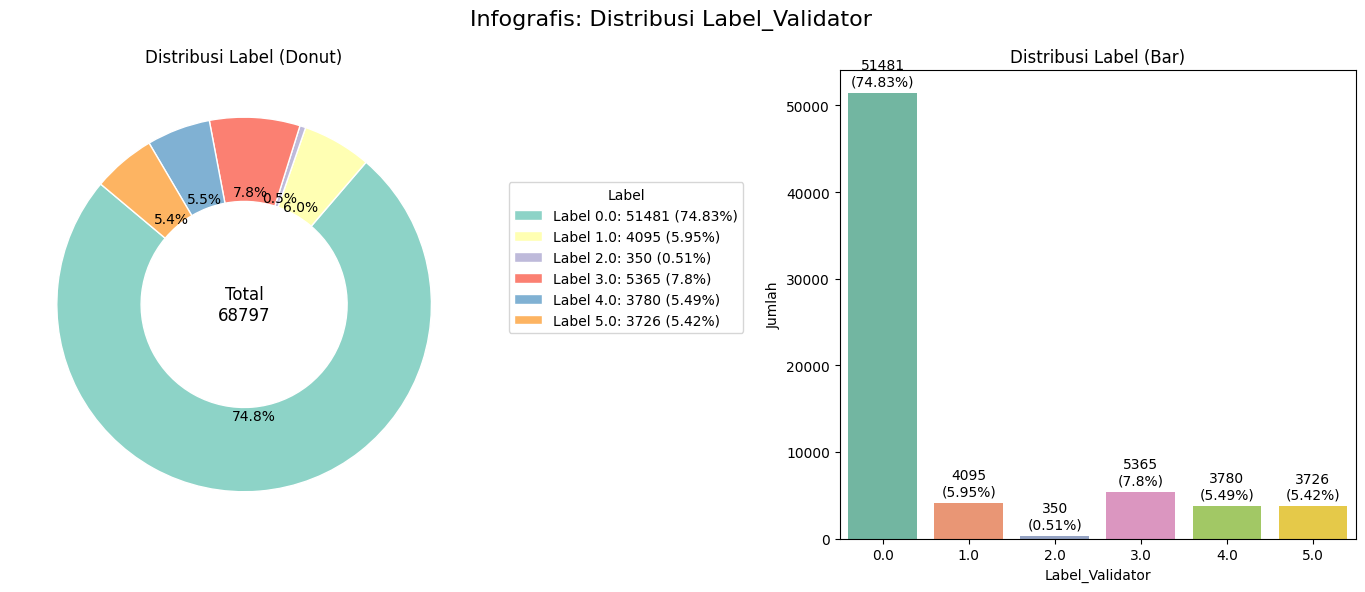

In [6]:
import seaborn as sns

# Infografis: Distribusi Label_Validator (donut + bar) dan simpan gambar
import matplotlib.pyplot as plt

label_counts = df["Label_Validator"].value_counts().sort_index()
labels = label_counts.index.astype(str).tolist()
counts = label_counts.values
percent = (counts / counts.sum() * 100).round(2)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Donut chart
cmap = plt.cm.Set3
colors = cmap(range(len(labels)))
wedges, texts, autotexts = axs[0].pie(
    counts,
    labels=None,
    autopct=lambda p: f'{p:.1f}%',
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.45, edgecolor='w')
)
axs[0].set_title("Distribusi Label (Donut)")
axs[0].legend(
    wedges,
    [f'Label {lab}: {cnt} ({pct}%)' for lab, cnt, pct in zip(labels, counts, percent)],
    title="Label",
    bbox_to_anchor=(1.05, 0.6),
    loc='center left'
)
axs[0].text(0, 0, f'Total\n{counts.sum()}', ha='center', va='center', fontsize=12)

# Bar chart
sns.barplot(x=labels, y=counts, palette='Set2', ax=axs[1])
for i, (c, p) in enumerate(zip(counts, percent)):
    axs[1].text(i, c + max(counts) * 0.01, f'{c}\n({p}%)', ha='center', va='bottom', fontsize=10)
axs[1].set_title("Distribusi Label (Bar)")
axs[1].set_xlabel("Label_Validator")
axs[1].set_ylabel("Jumlah")

plt.suptitle("Infografis: Distribusi Label_Validator", fontsize=16)
plt.tight_layout()
plt.savefig("infografis_distribusi_label.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_22456\2654136093.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts, palette='Set2')


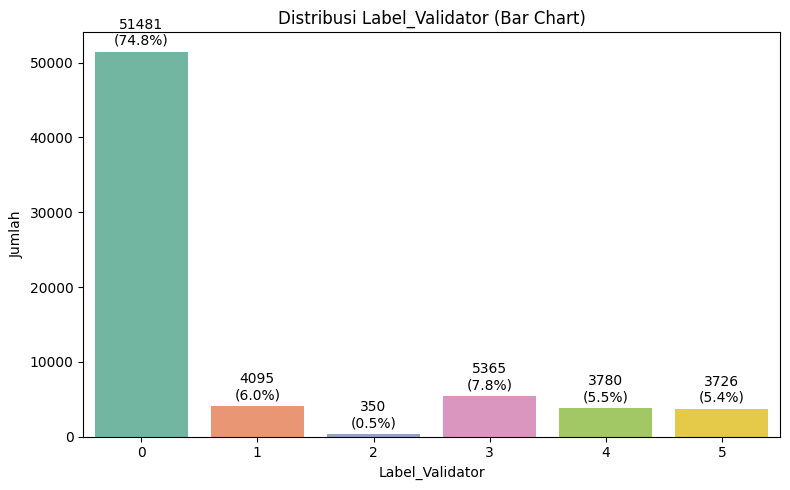

In [ ]:
import seaborn as sns

# Bar chart: jumlah data per Label_Validator (gunakan variable label_counts yang sudah ada)
import matplotlib.pyplot as plt

labels = [str(int(x)) for x in label_counts.index]  # convert 0.0 -> "0", etc.
counts = label_counts.values
percent = (counts / counts.sum()) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=labels, y=counts, palette='Set2')
ax.set_title("Distribusi Label_Validator (Bar Chart)")
ax.set_xlabel("Label_Validator")
ax.set_ylabel("Jumlah")

# tambahkan label jumlah + persen di atas tiap batang
max_count = counts.max()
for i, (c, p) in enumerate(zip(counts, percent)):
    ax.text(i, c + max_count * 0.01, f"{int(c)}\n({p:.1f}%)", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

label_counts = df["Label_Validator"].value_counts().sort_index()
labels = label_counts.index.astype(str).tolist()
counts = label_counts.values
percent = (counts / counts.sum() * 100).round(2)

C:\Users\Asus\AppData\Local\Temp\ipykernel_22456\3854450062.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts, palette='Set2')


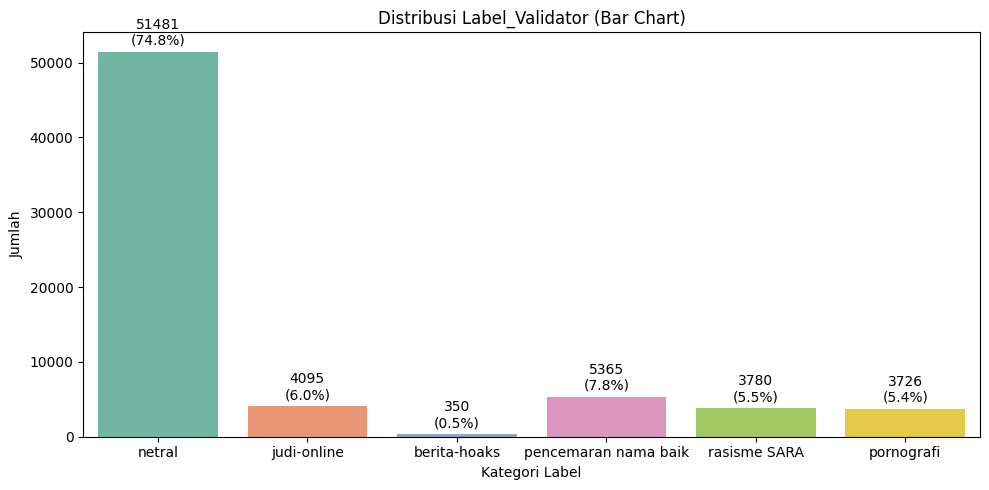

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# mapping label angka → label teks
label_map = {
    0: "netral",
    1: "judi-online",
    2: "berita-hoaks",
    3: "pencemaran nama baik",
    4: "rasisme SARA",
    5: "pornografi"
}

# hitung distribusi
label_counts = df["Label_Validator"].value_counts().sort_index()

# ubah angka menjadi label teks
labels = [label_map[int(x)] for x in label_counts.index]
counts = label_counts.values
percent = (counts / counts.sum()) * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=labels, y=counts, palette='Set2')

ax.set_title("Distribusi Label_Validator (Bar Chart)")
ax.set_xlabel("Kategori Label")
ax.set_ylabel("Jumlah")

# tambahkan angka + persentase di tiap batang
max_count = counts.max()
for i, (c, p) in enumerate(zip(counts, percent)):
    ax.text(i, c + max_count * 0.01, f"{int(c)}\n({p:.1f}%)",
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


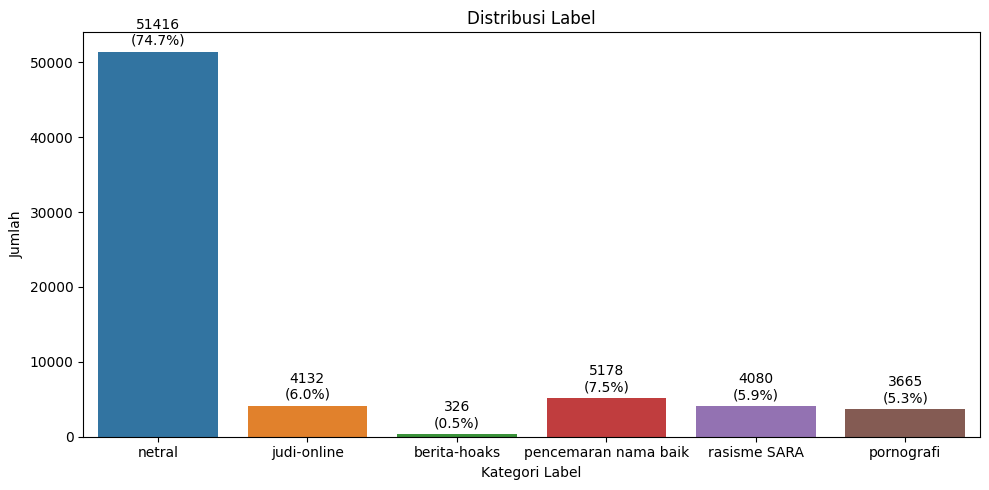

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping label angka → nama label
label_map = {
    0: "netral",
    1: "judi-online",
    2: "berita-hoaks",
    3: "pencemaran nama baik",
    4: "rasisme SARA",
    5: "pornografi"
}

# Ambil distribusi label
label_counts = df["Label"].value_counts().sort_index()

# Ubah index → label teks
labels = [label_map[int(x)] for x in label_counts.index]
counts = label_counts.values
percent = (counts / counts.sum()) * 100

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=labels,
    y=counts,
    hue=labels,    # pakai hue untuk menghindari warning
    legend=False   # matikan legend karena redundant
)

ax.set_title("Distribusi Label")
ax.set_xlabel("Kategori Label")
ax.set_ylabel("Jumlah")

# Tambahkan teks jumlah + persentase
max_count = counts.max()
for i, (c, p) in enumerate(zip(counts, percent)):
    ax.text(i, c + max_count * 0.01, f"{int(c)}\n({p:.1f}%)",
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("distribusi_label.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_22456\3665941528.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts, palette=colors)


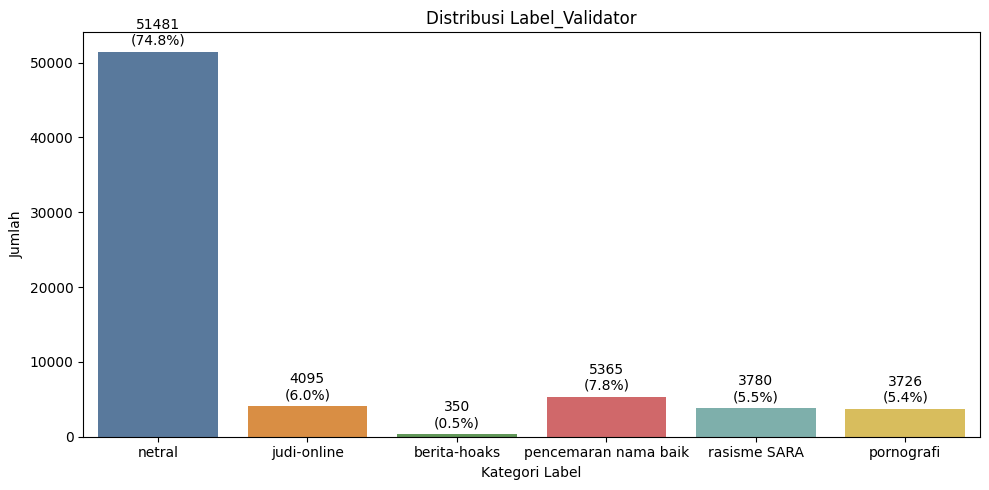

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping label angka → nama label
label_map = {
    0: "netral",
    1: "judi-online",
    2: "berita-hoaks",
    3: "pencemaran nama baik",
    4: "rasisme SARA",
    5: "pornografi"
}

# Ambil distribusi label
label_counts = df["Label_Validator"].value_counts().sort_index()

# Ubah index (angka) menjadi label teks
labels = [label_map[int(x)] for x in label_counts.index]
counts = label_counts.values
percent = (counts / counts.sum()) * 100

# Pilih warna berbeda
colors = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#76B7B2", "#EDC948"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=labels, y=counts, palette=colors)

ax.set_title("Distribusi Label_Validator")
ax.set_xlabel("Kategori Label")
ax.set_ylabel("Jumlah")

# Tambahkan jumlah + persentase di atas batang
max_count = counts.max()
for i, (c, p) in enumerate(zip(counts, percent)):
    ax.text(i, c + max_count * 0.01, f"{int(c)}\n({p:.1f}%)",
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("distribusi_label-validator.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
#

In [ ]:
    # =====================
# 3. Panjang Komentar
# =====================
df["comment_length"] = df["Komentar_bersih"].astype(str).apply(len)

print("\nRata-rata panjang komentar:", df["comment_length"].mean())

print("\n10 komentar terpanjang:")
print(df.nlargest(10, "comment_length")[["Komentar_bersih", "comment_length"]])

print("\n10 komentar terpendek:")
print(df.nsmallest(10, "comment_length")[["Komentar_bersih", "comment_length"]])


Rata-rata panjang komentar: 65.28193089814962

10 komentar terpanjang:
                                         Komentar_bersih  comment_length
9545   plisss tangkap anis emoji_enraged_face emoji_e...            5879
59448  dalam islam perselingkuhan termasuk perbuatan ...            3437
68005  nabi saw berkata apabila kita dimasukkan ke da...            3191
59333  jangan dikasih panggung iniih si pakde dhani g...            2070
33658  cadangan migas terbanyak di jawa blok cepu kil...            1857
35537  mention_user mineral logam emas ada tambang em...            1792
33597  mineral logam emas ada tambang emas di beberap...            1779
33654  mineral logam emas ada tambang emas di beberap...            1779
35585  mineral logam emas ada tambang emas di beberap...            1779
35587  mineral logam emas ada tambang emas di beberap...            1779

10 komentar terpendek:
      Komentar_bersih  comment_length
17810             l 1               3
40102             a 1    

In [15]:
# Komentar ditulis langsung di variabel
komentar = "Ini adalah contoh komentar dari user 😁🔥"
# Panjang karakter
panjang_karakter = len(komentar)

# Panjang kata
panjang_kata = len(komentar.split())

print("Komentar:", komentar)
print("Panjang karakter:", panjang_karakter)
print("Panjang kata:", panjang_kata)


Komentar: Ini adalah contoh komentar dari user 😁🔥
Panjang karakter: 39
Panjang kata: 7


In [16]:
# Komentar ditulis langsung di variabel
komentar = df.loc[df['Indeks'] == 9546, 'Komentar_bersih'].values[0]
# Panjang karakter
panjang_karakter = len(komentar)

# Panjang kata
panjang_kata = len(komentar.split())

print("Komentar:", komentar)
print("Panjang karakter:", panjang_karakter)
print("Panjang kata:", panjang_kata)


Komentar: plisss tangkap anis emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face dia lah yang bertanggung jawab atas semua ini emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enraged_face emoji_enrage

In [17]:
# =====================
# 3. Panjang Komentar (berdasarkan jumlah kata)
# =====================
df["comment_length"] = df["Komentar_bersih"].astype(str).apply(lambda x: len(x.split()))

print("\nRata-rata panjang komentar (dalam kata):", df["comment_length"].mean())

print("\n10 komentar terpanjang (jumlah kata):")
print(df.nlargest(10, "comment_length")[["Komentar_bersih", "comment_length"]])

print("\n10 komentar terpendek (jumlah kata):")
print(df.nsmallest(10, "comment_length")[["Komentar_bersih", "comment_length"]])



Rata-rata panjang komentar (dalam kata): 8.659650856868758

10 komentar terpanjang (jumlah kata):
                                         Komentar_bersih  comment_length
68005  nabi saw berkata apabila kita dimasukkan ke da...             517
59448  dalam islam perselingkuhan termasuk perbuatan ...             481
9545   plisss tangkap anis emoji_enraged_face emoji_e...             317
33658  cadangan migas terbanyak di jawa blok cepu kil...             291
59333  jangan dikasih panggung iniih si pakde dhani g...             282
35537  mention_user mineral logam emas ada tambang em...             279
33597  mineral logam emas ada tambang emas di beberap...             278
33654  mineral logam emas ada tambang emas di beberap...             278
35585  mineral logam emas ada tambang emas di beberap...             278
35587  mineral logam emas ada tambang emas di beberap...             278

10 komentar terpendek (jumlah kata):
                                         Komentar_bersih  co

In [21]:
jumlah_komentar_1_4_karakter = df["Komentar_bersih"].astype(str).apply(len).between(1, 5).sum()
print("Jumlah komentar dengan 1-4 karakter:", jumlah_komentar_1_4_karakter)

Jumlah komentar dengan 1-4 karakter: 87


In [30]:
komentar_pendek = df[df["Komentar_bersih"].astype(str).apply(len).between(1, 6)]["Komentar_bersih"]
print(komentar_pendek.tolist())

['jp in', '30 cm', 'u hama', 'tai lu', 'ceh ba', 'xnx x', 'oke bg', 'gw k', 'oh yaa', 'dm yee', 'me too', 'b aja', '09 09', 'dk doo', 'dku jg', 'l1 tmn', 'l 1', 'ep pa', 'bbl dd', 'dc f', 'b hr', 'yh j', 'yey ah', 'bgi bg', 'iya bg', 'iya bg', 'nk oi', '4 km', 'aw aw', 'ah kok', 'p info', 'bor up', 'hy kk', 'iy mw', 'iya bg', 'p 150', 'main k', 'oh ya?', 'b aja', 'dh lh', '20 25', 'you so', 'cek dm', 'lah ??', 'ga lah', 'oh yh', 'ya lh', 'fyp ya', 'cil ff', 'so y', 'hi buy', 'apa bg', 'ke 218', 'mass ?', 'up up', 'kamp g', 'lo aja', 'ff ff', 'ts pmo', 'lalu ?', 'jam 5', '12 59', 'hbd ya', 'hbd ka', 'ke 3', 'ada kk', 'ak 47', 'iya ka', 'lu tuh', 'lu aja', 'fr bro', 'se7 gw', 'up up', 'up up', 'iyh ih', 'e emm', 'hm fr', 'me too', 'oh ok', 'up up', 'up up', 'lh lol', 'pp lu?', '2 siss', 'me too', 'bf 023', 'ooh ya', 'nmr wa', 'hah ka', 'bls ya', 'ok dee', '95 5', 'gk mau', 'uhh ah', 'gk mau', 'a 1', 'eoe e', 'uu no', 'hey yo', 'oh xx', 'tt nya', '20 1', 'kak 90', 'nk tgk', 'y u', '2 mnt'

In [31]:
komentar_pendek = df[df["Komentar_bersih"].astype(str).apply(len).between(1, 6)]["Komentar_bersih"]
print(komentar_pendek.to_frame())

      Komentar_bersih
1077            jp in
1329            30 cm
5645           u hama
7578           tai lu
8261           ceh ba
...               ...
66459          i like
66630           un no
66888          iya om
67292          i like
68039          ewe bg

[214 rows x 1 columns]


In [32]:
# =====================
#  hapus komentar pendek)
# =====================
df = df[~df["Komentar_bersih"].astype(str).apply(len).between(1, 6)]
df.reset_index(drop=True, inplace=True)

In [33]:
# =====================
# 2. Distribusi Label(cek setelah hapus komentar pendek)
# =====================
print("\nDistribusi Label_Validator:")
print(df["Label_Validator"].value_counts())

print("\nDistribusi Label:")
print(df["Label"].value_counts())


Distribusi Label_Validator:
Label_Validator
0    51273
3     5362
1     4094
4     3780
5     3724
2      350
Name: count, dtype: int64

Distribusi Label:
Label
0    51208
3     5175
1     4131
4     4080
5     3663
2      326
Name: count, dtype: int64


In [34]:
# Menghitung jumlah token (kata) per komentar
df['jumlah_token'] = df['Komentar_bersih'].astype(str).apply(lambda x: len(x.split()))
print(df[['Komentar_bersih', 'jumlah_token']].head())

                                     Komentar_bersih  jumlah_token
0  mention_maplay789 emoji_black_heart withdraw n...             6
1  mention_maplay789 emoji_green_heart congratula...             4
2  mention_macanhoki789 emoji_yellow_heart emoji_...             8
3  mention_macanhoki789 emoji_yellow_heart emoji_...             8
4                                        pulen pulen             2


In [36]:
max_token = df['jumlah_token'].max()
min_token = df['jumlah_token'].min()

print("Jumlah token terbanyak:", max_token)
print("Jumlah token rata-rata:", df['jumlah_token'].mean())
print("Jumlah token terpendek:", min_token)

Jumlah token terbanyak: 517
Jumlah token rata-rata: 8.680474753218729
Jumlah token terpendek: 0


In [37]:
print(df["jumlah_token"].describe())


count    68583.000000
mean         8.680475
std         10.237556
min          0.000000
25%          4.000000
50%          6.000000
75%         10.000000
max        517.000000
Name: jumlah_token, dtype: float64


In [38]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 1.2 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.1 MB 1.6 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.1 MB 1.7 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.1 MB 2.2 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.1 MB 2.5 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 2.4 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.1 MB 2.5 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.1 MB 2.6 MB/s eta 0:00:02
   ---------------------------- ----------- 5.8/8.1 MB 2.6 MB/s eta 0:00:01
   -------------------------------- ------- 6


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


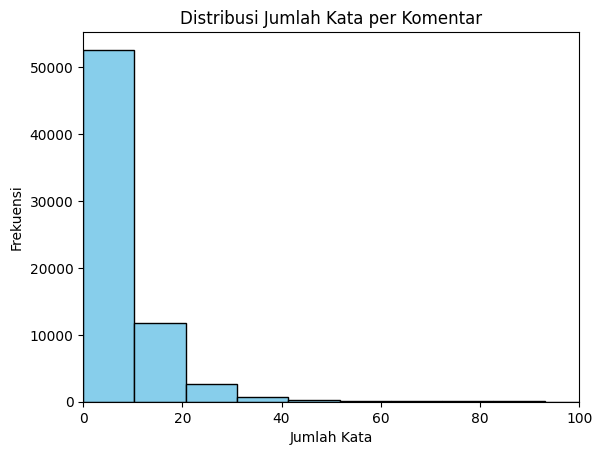

In [39]:
import matplotlib.pyplot as plt

plt.hist(df["jumlah_token"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribusi Jumlah Kata per Komentar")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.xlim(0, 100)  # fokus ke komentar pendek-sedang
plt.show()


In [41]:
max_len = int(df["jumlah_token"].quantile(0.95))
print("Max length (95th percentile):", max_len)
max_len_99 = int(df["jumlah_token"].quantile(0.99))
print("Max length (99th percentile):", max_len_99)


Max length (95th percentile): 22
Max length (99th percentile): 44


In [42]:
# =====================
# 3. Panjang Komentar per Label_Validator
print(df.groupby("Label_Validator")["comment_length"].describe())
# =====================
df["comment_length"] = df["Komentar_bersih"].astype(str).apply(lambda x: len(x.split()))

print("\nRata-rata panjang komentar (dalam kata):", df["comment_length"].mean())

print("\n10 komentar terpanjang (jumlah kata):")
print(df.nlargest(10, "comment_length")[["Komentar_bersih", "comment_length"]])

print("\n10 komentar terpendek (jumlah kata):")
print(df.nsmallest(10, "comment_length")[["Komentar_bersih", "comment_length"]])


                   count       mean        std  min  25%   50%   75%    max
Label_Validator                                                            
0                51273.0   8.230258  10.431833  0.0  4.0   6.0   9.0  517.0
1                 4094.0  10.308745   5.100594  2.0  7.0   9.0  12.0   70.0
2                  350.0  15.971429  14.906558  2.0  7.0  12.0  20.0  141.0
3                 5362.0  10.122902  10.896813  2.0  4.0   7.0  12.0  151.0
4                 3780.0  10.764815  10.906516  2.0  5.0   8.0  14.0  317.0
5                 3724.0   8.211332   8.515374  2.0  4.0   6.0  10.0  159.0

Rata-rata panjang komentar (dalam kata): 8.680474753218729

10 komentar terpanjang (jumlah kata):
                                         Komentar_bersih  comment_length
67792  nabi saw berkata apabila kita dimasukkan ke da...             517
59272  dalam islam perselingkuhan termasuk perbuatan ...             481
9540   plisss tangkap anis emoji_enraged_face emoji_e...             317
3

<Figure size 800x500 with 0 Axes>

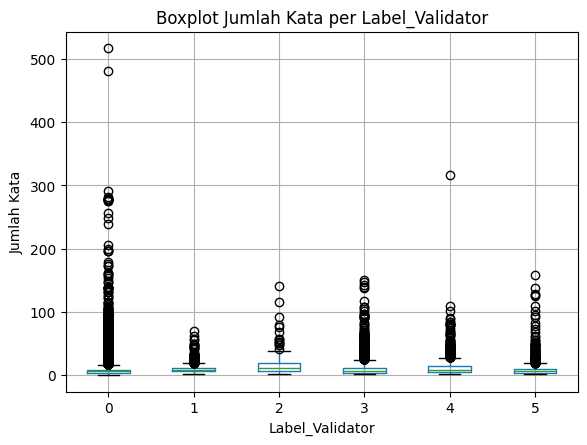

In [43]:
plt.figure(figsize=(8, 5))
df.boxplot(column='jumlah_token', by='Label_Validator')
plt.title('Boxplot Jumlah Kata per Label_Validator')
plt.suptitle('')
plt.xlabel('Label_Validator')
plt.ylabel('Jumlah Kata')
plt.show()

In [50]:
# Deteksi outlier komentar super panjang per label
# Misal threshold: komentar dengan jumlah_token > max_len_99 (99th percentile)

outlier_df = df[df['jumlah_token'] > max_len]

# Tampilkan contoh outlier per label
for label in outlier_df['Label_Validator'].unique():
    contoh = outlier_df[outlier_df['Label_Validator'] == label].head(3)
    print(f"\nLabel_Validator: {label}")
    # Simpan semua komentar outlier ke CSV
    outlier_df[['Komentar_bersih', 'jumlah_token']].to_csv('outlier_komentar.csv', index=False)
    print(contoh[['Komentar_bersih', 'jumlah_token']])


Label_Validator: 1
                                      Komentar_bersih  jumlah_token
63  link0 gass masuk sini grup diskusi parlay terb...            28
87  yang bingung cara main prly tapi gak ada boleh...            24
89  link0 gass masuk sini grup diskusi parlay terb...            28

Label_Validator: 2
                                       Komentar_bersih  jumlah_token
883  jadi alasan knp bpk maruf amin bilang kebanyak...            23
890  mention_user jadi alasan knp bpk maruf amin bi...            25
956  sudah ada klarifikasi dari pertamina untuk men...            24

Label_Validator: 3
                                       Komentar_bersih  jumlah_token
887  gaboleh suudzon krn hanya allah yang tahu tapi...            28
889  bodo amat oknum pmrnth koruptor mah hrsnya dse...            36
891  semoga jadi ladang pahala buat kita yg di dzol...            27

Label_Validator: 4
                                        Komentar_bersih  jumlah_token
1366  sama sound horeg tid

In [46]:
# Hitung proporsi outlier per label
proporsi_outlier = (
    outlier_df.groupby('Label_Validator').size() / df.groupby('Label_Validator').size() * 100
).round(2)

print("Proporsi outlier per label (%):")
print(proporsi_outlier)

Proporsi outlier per label (%):
Label_Validator
0    0.90
1    0.22
2    4.00
3    1.66
4    1.24
5    0.75
dtype: float64


In [48]:
# =====================
# Deteksi Outlier Komentar Panjang per Label
# =====================

import pandas as pd

# Hitung jumlah kata
df["jumlah_token"] = df["Komentar_bersih"].astype(str).apply(lambda x: len(x.split()))

# Fungsi untuk ambil komentar outlier per label
def get_outliers_by_label(df, label, quantile=0.95):
    subset = df[df["Label_Validator"] == label]
    threshold = subset["jumlah_token"].quantile(quantile)  # ambil batas quantile
    outliers = subset[subset["jumlah_token"] > threshold]
    return outliers.sort_values("jumlah_token", ascending=False).head(5)[["Komentar_bersih", "jumlah_token"]]

# Tampilkan 5 outlier terpanjang per label
for label in sorted(df["Label_Validator"].unique()):
    print(f"\n=== Label {label} ===")
    print(get_outliers_by_label(df, label, quantile=0.95))



=== Label 0 ===
                                         Komentar_bersih  jumlah_token
67792  nabi saw berkata apabila kita dimasukkan ke da...           517
59272  dalam islam perselingkuhan termasuk perbuatan ...           481
33590  cadangan migas terbanyak di jawa blok cepu kil...           291
59157  jangan dikasih panggung iniih si pakde dhani g...           282
35467  mention_user mineral logam emas ada tambang em...           279

=== Label 1 ===
                                         Komentar_bersih  jumlah_token
17236  baru pertama kali mendengar kan khw ini sambil...            70
13743  dari awal sampai akhir aku nggak bisa berhenti...            62
16485  labuan 4 d situs exclusive game slot dari serv...            58
17310  udah tau salah tp kok gaada yg tegas nolak dr ...            55
14178  udah tau belum kalo di online138 bawa modal be...            49

=== Label 2 ===
                                         Komentar_bersih  jumlah_token
11345  mention_user p ment

In [52]:
# =====================
# Simpan Semua Outlier Komentar ke CSV + Hitung Jumlah Outlier per Label
# =====================

import pandas as pd

# Hitung jumlah kata
df["num_words"] = df["Komentar_bersih"].astype(str).apply(lambda x: len(x.split()))

# Ambil semua outlier per label (di atas quantile 0.95)
outlier_list = []
outlier_stats = []  # simpan jumlah outlier per label

for label in sorted(df["Label_Validator"].unique()):
    subset = df[df["Label_Validator"] == label]
    threshold = subset["num_words"].quantile(0.95)  # batas outlier per label
    outliers = subset[subset["num_words"] > threshold]
    outliers = outliers.assign(Threshold=threshold)  # tambahkan info threshold
    outlier_list.append(outliers)

    # simpan statistik jumlah outlier
    outlier_stats.append({
        "Label_Validator": label,
        "Threshold": threshold,
        "Jumlah_Outlier": len(outliers)
    })

# Gabungkan semua outlier jadi satu dataframe
outliers_all = pd.concat(outlier_list)

# Pilih kolom yang penting
outliers_all = outliers_all[["Label", "Label_Validator", "Komentar_bersih", "num_words", "Threshold"]]

# Simpan ke CSV
outliers_all.to_csv("outlier_komentar.csv", index=False, encoding="utf-8-sig")

# Buat DataFrame statistik per label
outlier_stats_df = pd.DataFrame(outlier_stats)

print("✅ Outlier komentar sudah disimpan ke 'outlier_komentar.csv'")
print("\nJumlah total outlier:", len(outliers_all))
print("\nJumlah outlier per label:")
print(outlier_stats_df)


✅ Outlier komentar sudah disimpan ke 'outlier_komentar.csv'

Jumlah total outlier: 3201

Jumlah outlier per label:
   Label_Validator  Threshold  Jumlah_Outlier
0                0      22.00            2375
1                1      18.00             202
2                2      37.55              18
3                3      28.00             255
4                4      28.00             168
5                5      19.00             183


In [60]:
# =====================
# Distribusi Emoji per Label_Validator
# =====================

import pandas as pd
import re
from collections import Counter

# Fungsi untuk ekstrak emoji tokens dari komentar
def extract_emojis(text):
    # Cari semua token yang bermula dengan 'emoji_'
    emojis = re.findall(r'emoji_[a-zA-Z_]+', str(text))
    return emojis

# Tambah kolom list emoji per komentar
df['emojis'] = df['Komentar_bersih'].apply(extract_emojis)

# Flatten semua emoji per label dan hitung frekuensi
emoji_dist = {}
for label in sorted(df['Label_Validator'].unique()):
    subset = df[df['Label_Validator'] == label]
    all_emojis = [emoji for sublist in subset['emojis'] for emoji in sublist]
    emoji_dist[label] = Counter(all_emojis)

# Buat DataFrame untuk distribusi
emoji_df_list = []
for label, counter in emoji_dist.items():
    for emoji, count in counter.items():
        emoji_df_list.append({'Label_Validator': label, 'Emoji': emoji, 'Count': count})

emoji_df = pd.DataFrame(emoji_df_list)

# Tambah kolom Emoji_Asli
emoji_df['Emoji_Asli'] = emoji_df['Emoji'].apply(token_to_emoji)

# Debug: print beberapa contoh
print("Contoh convert emoji:")
for i in range(5):
    token = emoji_df['Emoji'].iloc[i]
    asli = emoji_df['Emoji_Asli'].iloc[i]
    print(f"{token} -> {asli}")

# Simpan ke CSV
emoji_df.to_csv('emoji_distribution_per_label.csv', index=False)

# Pivot table untuk ringkasan
pivot_emoji = emoji_df.pivot_table(index='Emoji', columns='Label_Validator', values='Count', fill_value=0)

print("✅ Distribusi emoji per label disimpan ke 'emoji_distribution_per_label.csv'")
print("\nTop 5 emoji per label:")
for label in sorted(df['Label_Validator'].unique()):
    top_emojis = emoji_df[emoji_df['Label_Validator'] == label].nlargest(5, 'Count')
    print(f"\nLabel {label}:")
    print(top_emojis[['Emoji', 'Count']])

# Tampilkan pivot table (ringkasan)
print("\nPivot table distribusi emoji (top 10 emoji):")
# Hitung sum per emoji dan sort descending
emoji_sums = pivot_emoji.sum(axis=1).sort_values(ascending=False)
top_10_emojis = emoji_sums.head(10).index
print(pivot_emoji.loc[top_10_emojis])

Contoh convert emoji:
emoji_loudly_crying_face -> emoji_loudly_crying_face
emoji_rolling_on_the_floor_laughing -> emoji_rolling_on_the_floor_laughing
emoji_face_with_tears_of_joy -> emoji_face_with_tears_of_joy
emoji_face_with_hand_over_mouth -> emoji_face_with_hand_over_mouth
emoji_smiling_face_with_hearts -> emoji_smiling_face_with_hearts
✅ Distribusi emoji per label disimpan ke 'emoji_distribution_per_label.csv'

Top 5 emoji per label:

Label 0:
                                 Emoji  Count
0             emoji_loudly_crying_face   8164
2         emoji_face_with_tears_of_joy   5437
1  emoji_rolling_on_the_floor_laughing   3528
6                           emoji_moai   2357
9                   emoji_folded_hands   1416

Label 1:
                  Emoji  Count
914  emoji_victory_hand    353
778          emoji_fire    333
748   emoji_black_heart    319
781      emoji_yin_yang    238
995    emoji_heart_suit    236

Label 2:
                                     Emoji  Count
1220   emoji_ro

C:\Users\Asus\AppData\Local\Temp\ipykernel_24672\1314221351.py:37: UserWarning: Glyph 129315 (\N{ROLLING ON THE FLOOR LAUGHING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_24672\1314221351.py:37: UserWarning: Glyph 128511 (\N{MOYAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_24672\1314221351.py:37: UserWarning: Glyph 128591 (\N{PERSON WITH FOLDED HANDS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_24672\1314221351.py:37: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_24672\1314221351.py:37: UserWarning: Glyph 128420 (\N{BLACK HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\kuliah\uu-ite\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129315 (\N{ROLLING ON THE FLOOR LAUGHING}) missing from font

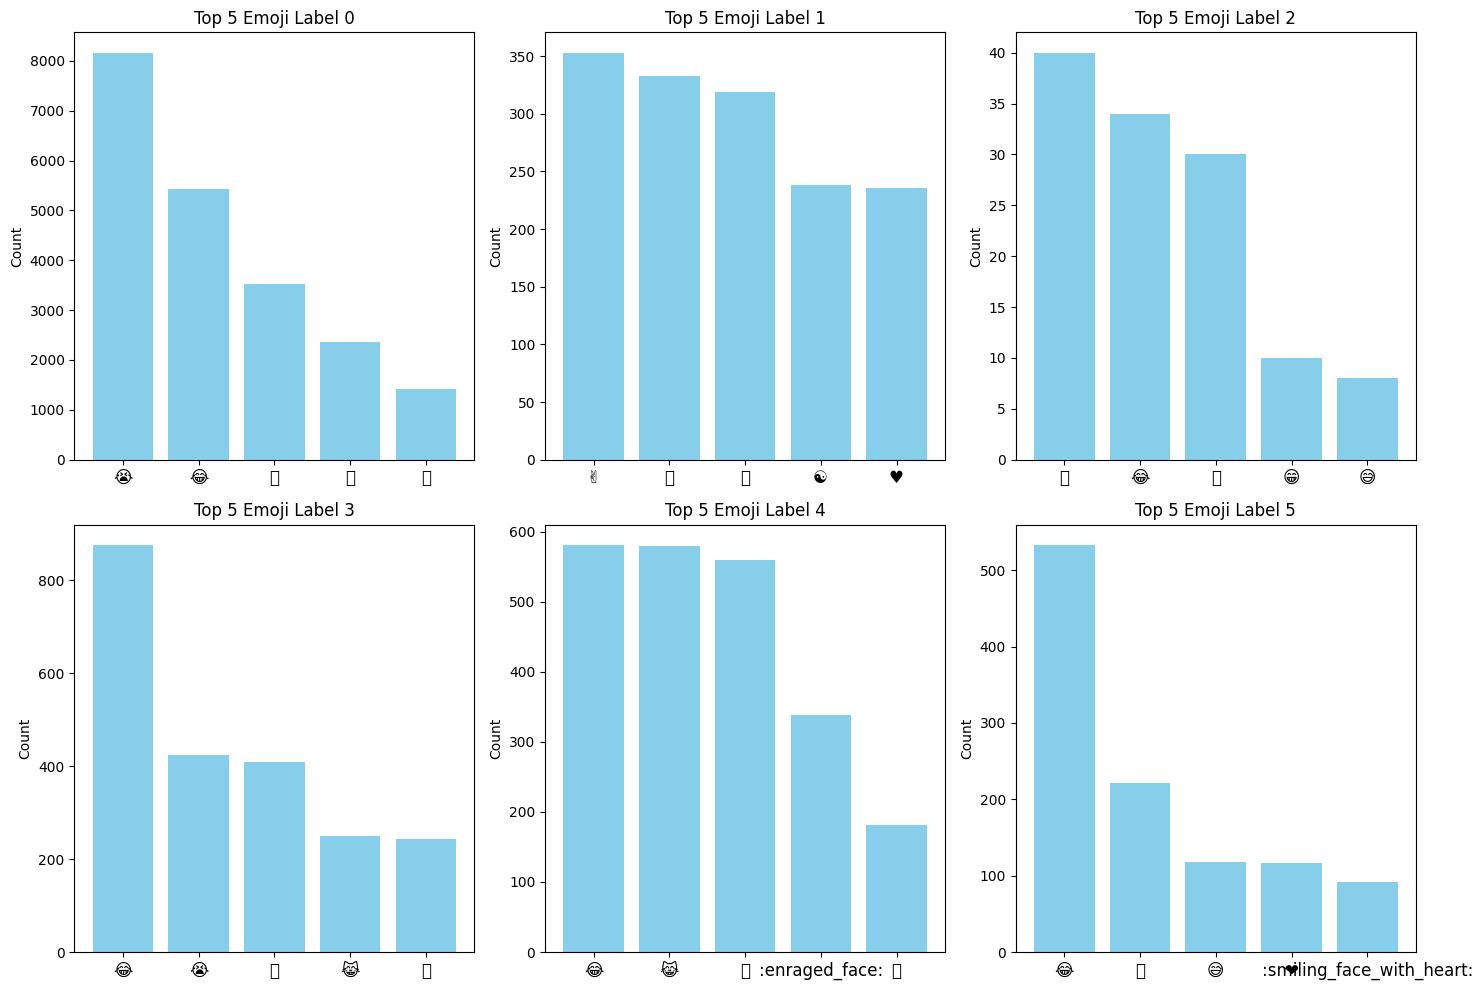

d:\kuliah\uu-ite\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129315 (\N{ROLLING ON THE FLOOR LAUGHING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\kuliah\uu-ite\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128511 (\N{MOYAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\kuliah\uu-ite\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128591 (\N{PERSON WITH FOLDED HANDS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\kuliah\uu-ite\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129392 (\N{SMILING FACE WITH SMILING EYES AND THREE HEARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


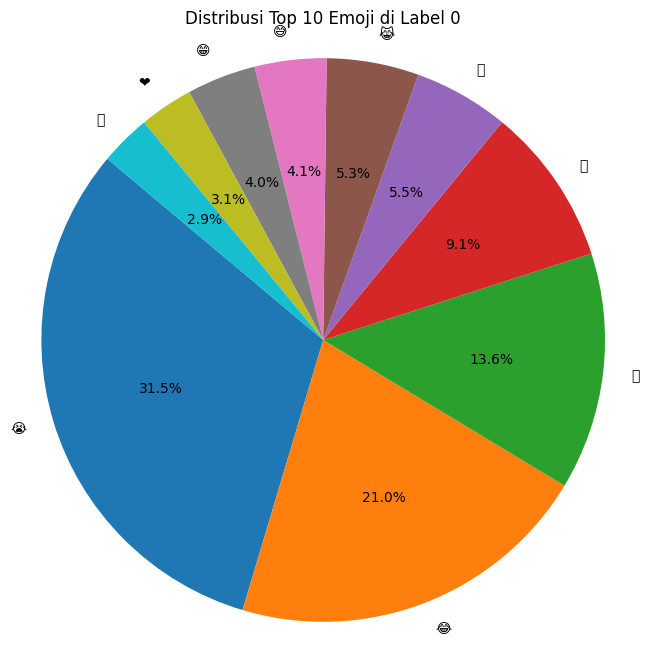

In [56]:
# =====================
# Visualisasi Distribusi Emoji per Label (dengan Emoji Asli)
# =====================

import matplotlib.pyplot as plt
import emoji

# Fungsi untuk convert token emoji ke emoji asli
def token_to_emoji(token):
    # Remove 'emoji_' prefix, keep underscore for emojize
    emoji_name = token.replace('emoji_', '')
    try:
        # Gunakan emoji.emojize dengan format :emoji_name:
        result = emoji.emojize(f":{emoji_name}:")
        # Jika sama dengan input, bermakna gagal convert
        if result == f":{emoji_name}:":
            return token  # fallback
        return result
    except:
        return token  # fallback jika gagal

# Tambah kolom emoji asli ke emoji_df
emoji_df['Emoji_Asli'] = emoji_df['Emoji'].apply(token_to_emoji)

# Plot top 5 emoji per label
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, label in enumerate(sorted(df['Label_Validator'].unique())):
    ax = axes[i]
    top_emojis = emoji_df[emoji_df['Label_Validator'] == label].nlargest(5, 'Count')
    emojis_asli = top_emojis['Emoji_Asli'].tolist()
    counts = top_emojis['Count'].tolist()

    ax.bar(range(len(emojis_asli)), counts, color='skyblue')
    ax.set_xticks(range(len(emojis_asli)))
    ax.set_xticklabels(emojis_asli, fontsize=12)
    ax.set_title(f'Top 5 Emoji Label {label}')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Alternatif: Pie chart untuk semua emoji di label tertentu (contoh label 0)
label_example = 0
top_emojis = emoji_df[emoji_df['Label_Validator'] == label_example].nlargest(10, 'Count')
emojis_asli = top_emojis['Emoji_Asli'].tolist()
counts = top_emojis['Count'].tolist()

plt.figure(figsize=(8, 8))
plt.pie(counts, labels=emojis_asli, autopct='%1.1f%%', startangle=140)
plt.title(f'Distribusi Top 10 Emoji di Label {label_example}')
plt.axis('equal')
plt.show()

In [57]:
print("Contoh convert:")
print("emoji_red_heart ->", token_to_emoji("emoji_red_heart"))
print("emoji_loudly_crying_face ->", token_to_emoji("emoji_loudly_crying_face"))

Contoh convert:
emoji_red_heart -> ❤️
emoji_loudly_crying_face -> 😭


In [3]:
import pandas as pd

df = pd.read_csv('data/dataset_with_index.csv')
df.head()

,Indeks,Komentar,Komentar_bersih,normal_teks,Label,Label_Validator
0,1,@𝙈𝙖𝙥𝙡𝙖𝙮𝟕𝟖𝟗 🖤 withdraw never die🖤,mention_maplay789 emoji_black_heart withdraw n...,mention_maplay789 emoji_black_heart penarikan ...,1,1.0
1,2,@𝙈𝙖𝙥𝙡𝙖𝙮𝟕𝟖𝟗 💚congratulations💚,mention_maplay789 emoji_green_heart congratula...,mention_maplay789 emoji_green_heart selamat em...,1,1.0
2,3,@macanhoki789 💛💜 only one brother💜💛,mention_macanhoki789 emoji_yellow_heart emoji_...,mention_macanhoki789 emoji_yellow_heart emoji_...,1,1.0
3,4,@macanhoki789 💛💜 give up brother💜💛,mention_macanhoki789 emoji_yellow_heart emoji_...,mention_macanhoki789 emoji_yellow_heart emoji_...,1,1.0
4,5,pulen pulen,pulen pulen,pulen pulen,5,5.0



=== Label 0.0 ===
emojiloudlycryingface: 1521
di: 1176
emojifacewithtearsofjoy: 1088
mentionuser: 1009
yg: 903
nya: 798
emojirollingonthefloorlaughing: 675
ini: 618
itu: 609
yang: 587

=== Label 1.0 ===
di: 1254
yang: 491
main: 450
banget: 371
emojivictoryhand: 353
emojifire: 333
a: 324
emojiblackheart: 319
alexis17: 305
7: 281

=== Label 2.0 ===
di: 146
yg: 95
itu: 92
ada: 79
aceh: 62
ini: 57
dan: 56
pulau: 54
nya: 53
mau: 47

=== Label 3.0 ===
emojifacewithtearsofjoy: 876
di: 690
lu: 683
yg: 626
nya: 564
dia: 476
emojiloudlycryingface: 425
ini: 421
orang: 412
emojirollingonthefloorlaughing: 410

=== Label 4.0 ===
palembang: 1178
di: 669
jawa: 632
yg: 624
emojifacewithtearsofjoy: 581
emojicatwithtearsofjoy: 580
agama: 564
emojirollingonthefloorlaughing: 559
tebak: 367
hama: 345

=== Label 5.0 ===
nya: 549
emojifacewithtearsofjoy: 533
di: 479
yg: 343
bang: 268
itu: 224
emojirollingonthefloorlaughing: 221
sama: 207
ini: 203
aja: 196


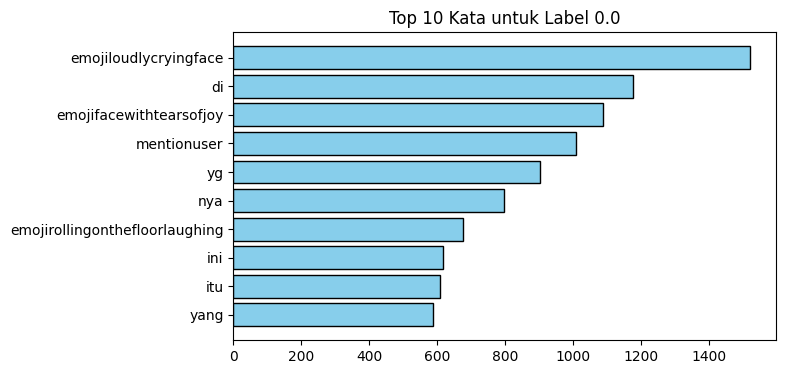

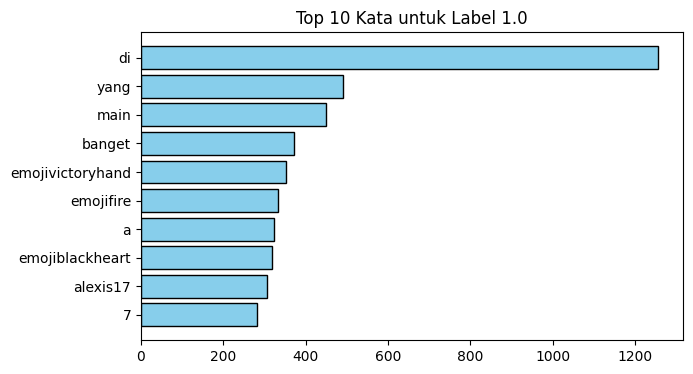

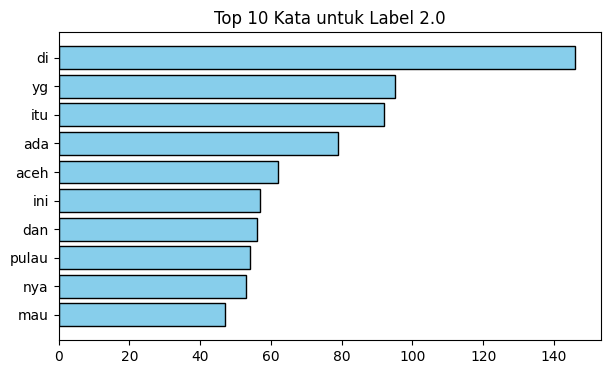

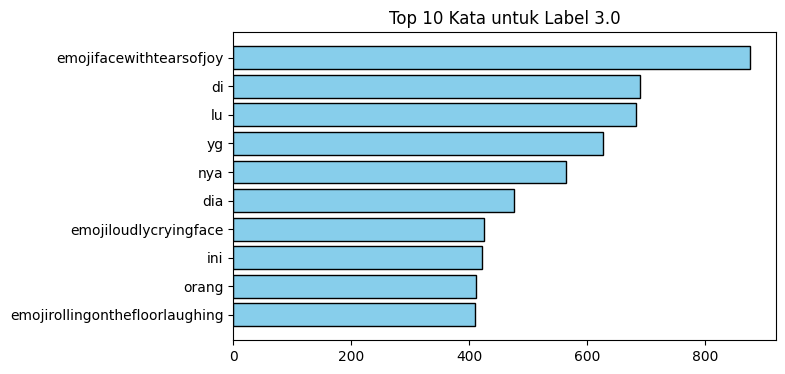

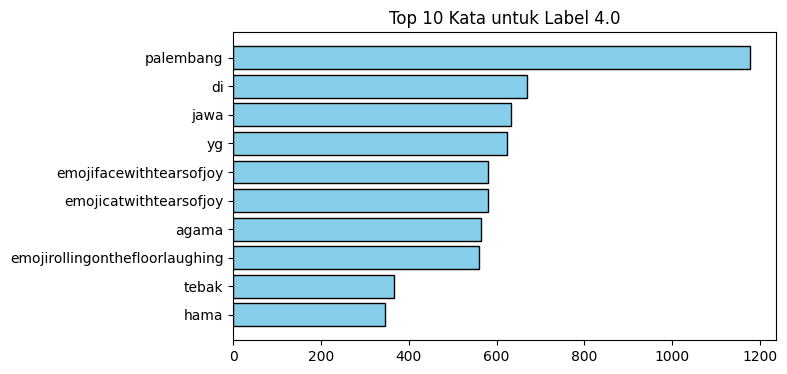

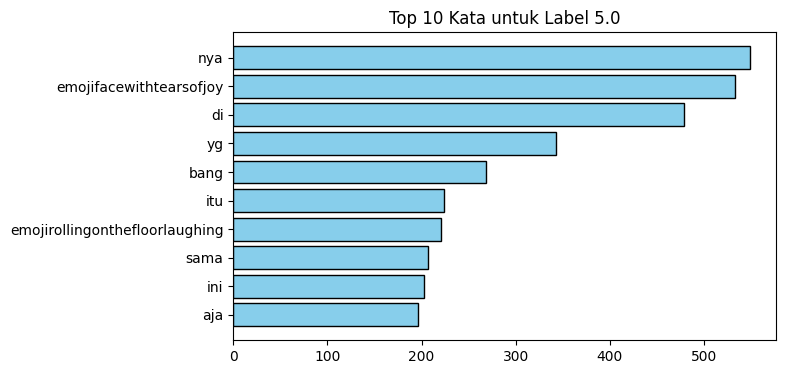

In [4]:
# =====================
# Top Words per Label
# =====================

import re
from collections import Counter
import matplotlib.pyplot as plt

# Fungsi tokenisasi sederhana
def tokenize(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)    # hapus URL
    text = re.sub(r"@\w+", "", text)       # hapus mention
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)  # hapus tanda baca
    return text.split()

# Cari top words per label
top_words_per_label = {}

for label in sorted(df["Label_Validator"].unique()):
    words = []
    texts = df[df["Label_Validator"] == label]["Komentar_bersih"].astype(str)
    
    # sampling kalau data terlalu besar
    if len(texts) > 10000:
        texts = texts.sample(10000, random_state=42)
    
    for text in texts:
        words.extend(tokenize(text))
    
    counter = Counter(words)
    top_words_per_label[label] = counter.most_common(10)

# Print hasil
for label, words in top_words_per_label.items():
    print(f"\n=== Label {label} ===")
    for word, count in words:
        print(f"{word}: {count}")

# Visualisasi barplot
for label, words in top_words_per_label.items():
    top_df = pd.DataFrame(words, columns=["word", "count"])
    plt.figure(figsize=(7,4))
    plt.barh(top_df["word"], top_df["count"], color="skyblue", edgecolor="black")
    plt.title(f"Top 10 Kata untuk Label {label}")
    plt.gca().invert_yaxis()
    plt.show()


Jumlah data per label:
Label_Validator
0.0    51481
1.0     4095
2.0      350
3.0     5365
4.0     3780
5.0     3726
Name: count, dtype: int64

🔎 Rasio mayoritas vs minoritas: 147.09:1


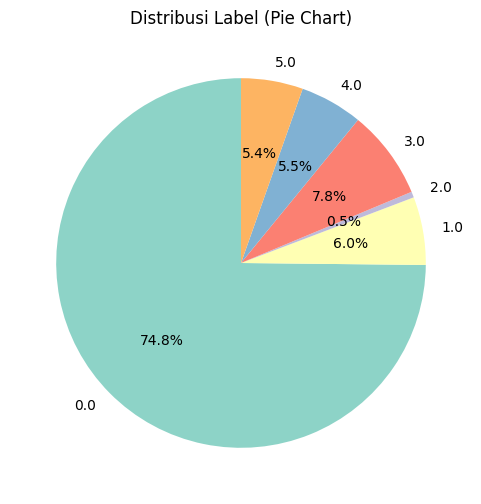

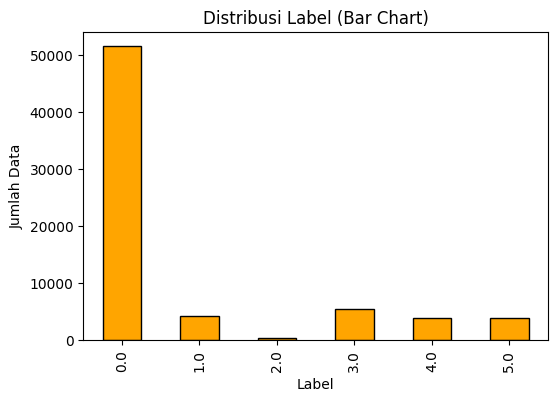

In [5]:
# =====================
# Imbalance Analysis
# =====================

import matplotlib.pyplot as plt

# Distribusi label
label_counts = df["Label_Validator"].value_counts().sort_index()

print("Jumlah data per label:")
print(label_counts)

# Hit ratio mayoritas vs minoritas
max_class = label_counts.max()
min_class = label_counts.min()
ratio = round(max_class / min_class, 2)

print(f"\n🔎 Rasio mayoritas vs minoritas: {ratio}:1")

# Pie chart distribusi label
plt.figure(figsize=(6,6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
plt.title("Distribusi Label (Pie Chart)")
plt.show()

# Bar chart distribusi label
plt.figure(figsize=(6,4))
label_counts.plot(kind="bar", color="orange", edgecolor="black")
plt.title("Distribusi Label (Bar Chart)")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")
plt.show()


In [6]:
# =====================
# Rasio Antar Kelas
# =====================

import pandas as pd

# Hitung jumlah data per label
label_counts = df["Label_Validator"].value_counts().sort_index()

# Buat DataFrame perbandingan rasio
ratio_matrix = pd.DataFrame(index=label_counts.index, columns=label_counts.index, dtype=float)

for i in label_counts.index:
    for j in label_counts.index:
        ratio_matrix.loc[i, j] = round(label_counts[i] / label_counts[j], 2)

print("📊 Rasio antar kelas (baris: dibandingkan dengan kolom):")
print(ratio_matrix)


📊 Rasio antar kelas (baris: dibandingkan dengan kolom):
Label_Validator   0.0    1.0     2.0   3.0    4.0    5.0
Label_Validator                                         
0.0              1.00  12.57  147.09  9.60  13.62  13.82
1.0              0.08   1.00   11.70  0.76   1.08   1.10
2.0              0.01   0.09    1.00  0.07   0.09   0.09
3.0              0.10   1.31   15.33  1.00   1.42   1.44
4.0              0.07   0.92   10.80  0.70   1.00   1.01
5.0              0.07   0.91   10.65  0.69   0.99   1.00


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


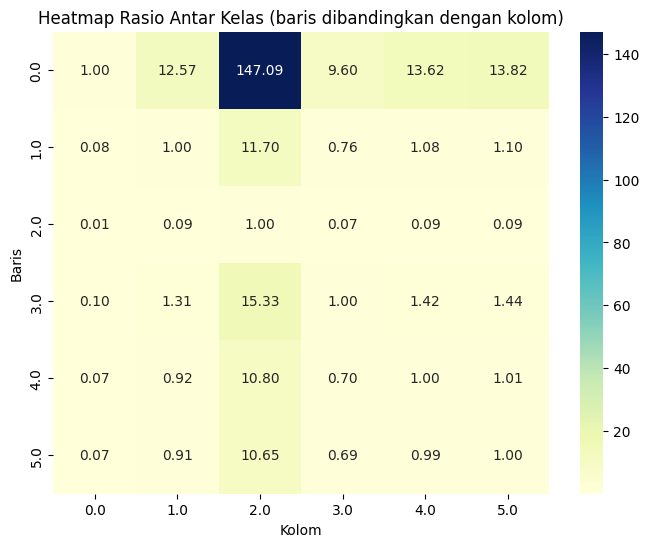

In [8]:
# =====================
# Heatmap Rasio Antar Kelas
# =====================

%pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt

# Hitung jumlah data per label
label_counts = df["Label_Validator"].value_counts().sort_index()

# Buat DataFrame rasio antar kelas
ratio_matrix = pd.DataFrame(index=label_counts.index, columns=label_counts.index, dtype=float)

for i in label_counts.index:
    for j in label_counts.index:
        ratio_matrix.loc[i, j] = round(label_counts[i] / label_counts[j], 2)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(ratio_matrix.astype(float), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Heatmap Rasio Antar Kelas (baris dibandingkan dengan kolom)")
plt.xlabel("Kolom")
plt.ylabel("Baris")
plt.show()


In [10]:
# =====================
# 9. Bigram / Trigram Analysis
# =====================

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Gunakan kolom komentar bersih
texts = df["Komentar"].astype(str).tolist()

# Analisis Bigram
vectorizer_bigram = CountVectorizer(ngram_range=(2,2), max_features=20, stop_words=None)
X_bigram = vectorizer_bigram.fit_transform(texts)
bigram_freq = dict(zip(vectorizer_bigram.get_feature_names_out(), X_bigram.sum(axis=0).A1))
bigram_sorted = sorted(bigram_freq.items(), key=lambda x: x[1], reverse=True)

print("🔹 Top 20 Bigram:")
for bg in bigram_sorted[:20]:
    print(bg)

# Analisis Trigram
vectorizer_trigram = CountVectorizer(ngram_range=(3,3), max_features=20, stop_words=None)
X_trigram = vectorizer_trigram.fit_transform(texts)
trigram_freq = dict(zip(vectorizer_trigram.get_feature_names_out(), X_trigram.sum(axis=0).A1))
trigram_sorted = sorted(trigram_freq.items(), key=lambda x: x[1], reverse=True)

print("\n🔹 Top 20 Trigram:")
for tg in trigram_sorted[:20]:
    print(tg)


🔹 Top 20 Bigram:
('paus fransiskus', 592)
('tebak agama', 394)
('ada yg', 316)
('salam toleransi', 302)
('your son', 282)
('educate your', 280)
('alis tebal', 279)
('main di', 279)
('ya allah', 254)
('di jawa', 250)
('ada yang', 244)
('yg di', 243)
('ga ada', 234)
('laki laki', 226)
('berduka cita', 220)
('bunda maia', 219)
('turut berduka', 219)
('gak ada', 215)
('dia mau', 185)
('ini mah', 180)

🔹 Top 20 Trigram:
('educate your son', 271)
('turut berduka cita', 181)
('not my style', 137)
('di jawa barat', 119)
('berduka cita atas', 113)
('diproduksi di jawa', 94)
('alergi dompet tipis', 92)
('paus fransiskus salam', 92)
('meninggalnya paus fransiskus', 87)
('palembang rakus palembang', 85)
('atas meninggalnya paus', 84)
('protect your daughter', 84)
('fransiskus salam toleransi', 83)
('palembang lapar palembang', 82)
('palembang rayap palembang', 82)
('rayap palembang rakus', 82)
('palembang prindapan palembang', 81)
('prindapan palembang ronghinya', 81)
('rakus palembang lapar', 81)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


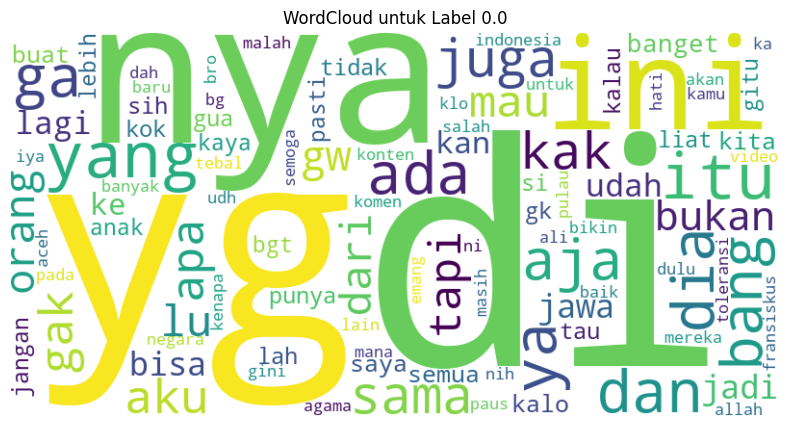

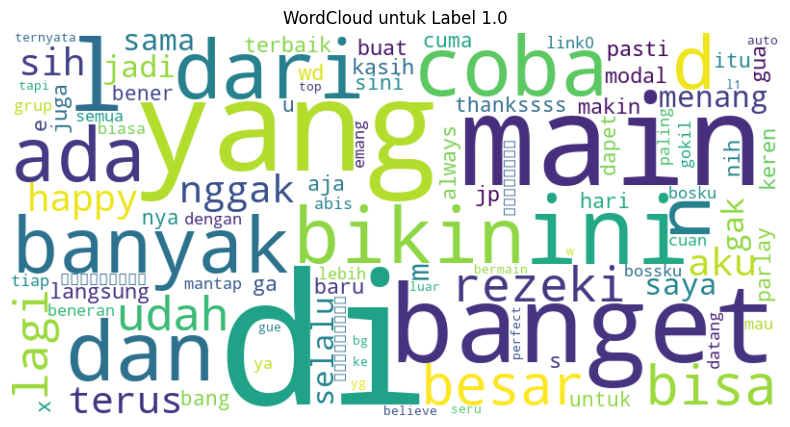

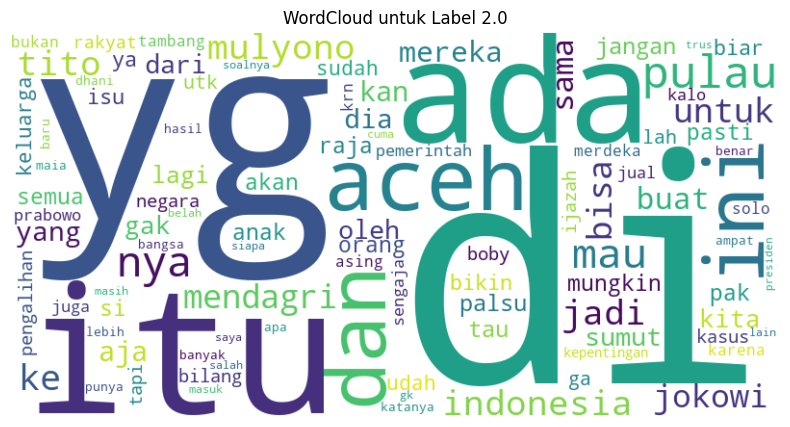

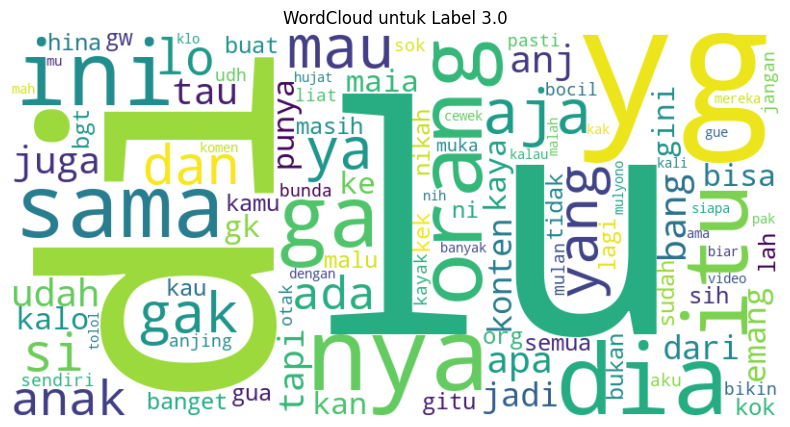

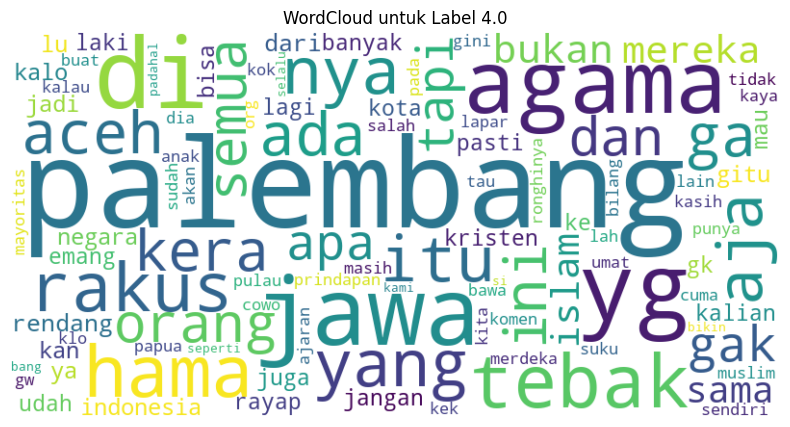

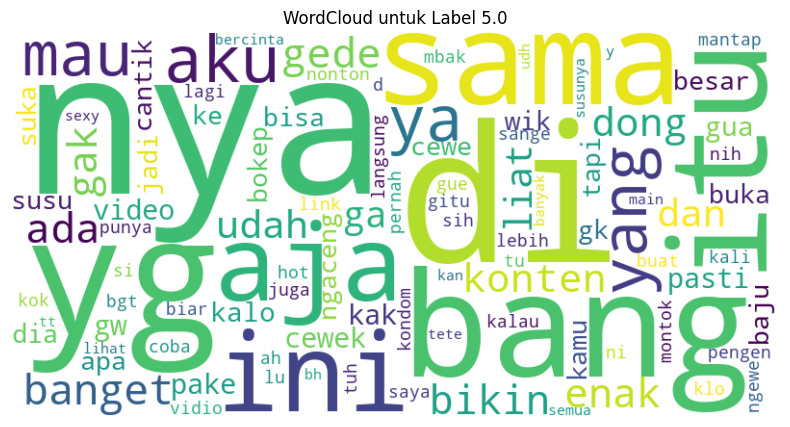

In [12]:
# =====================
# 10. WordCloud per Label
# =====================
%pip install wordcloud 
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# Fungsi tokenisasi sederhana
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)   # hapus URL
    text = re.sub(r"@\w+", "", text)      # hapus mention
    return text

# Buat WordCloud untuk setiap label
for label in sorted(df["Label_Validator"].unique()):
    texts = df[df["Label_Validator"] == label]["Komentar"].astype(str)
    
    # sampling jika terlalu banyak
    if len(texts) > 5000:
        texts = texts.sample(5000, random_state=42)
    
    all_text = " ".join([clean_text(t) for t in texts])
    
    wc = WordCloud(width=800, height=400,
                   background_color="white",
                   collocations=False, # biar kata tidak digabung
                   max_words=100).generate(all_text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud untuk Label {label}")
    plt.show()


In [ ]:
# =====================
# 12. Distribusi Bahasa / Slang
# =====================
# %pip install langdetect
from langdetect import detect, DetectorFactory
import re
from collections import Counter

DetectorFactory.seed = 0  # biar hasil konsisten

# Deteksi bahasa tiap komentar (sampling biar cepat)
sample_texts = df["Komentar_bersih"].astype(str).sample(5000, random_state=42)

languages = []
for text in sample_texts:
    try:
        lang = detect(text)
    except:
        lang = "unknown"
    languages.append(lang)

lang_counts = Counter(languages)

print("Distribusi Bahasa (sample 5000):")
print(lang_counts)



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------- ----------------------------- 262.1/981.5 kB ? eta -:--:--
     -------------------- ----------------- 524.3/981.5 kB 1.3 MB/s eta 0:00:01
     ------------------------------ ------- 786.4/981.5 kB 1.1 MB/s eta 0:00:01
     -------------------------------------- 981.5/981.5 kB 1.1 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993363 sha256=1e9226687bd0cc7c6578d3f4ca7a10e063fbbb49e87b07c3c5be91c5c13780bd
  Stored in directory: c:\users\asus\appdata\local

In [14]:
# =====================
# Deteksi Bahasa untuk Seluruh Data
# =====================

from langdetect import detect, DetectorFactory
from collections import Counter

DetectorFactory.seed = 0  # biar hasil konsisten

languages = []
for text in df["Komentar_bersih"].astype(str):
    try:
        lang = detect(text)
    except:
        lang = "unknown"
    languages.append(lang)

# Hitung distribusi bahasa
lang_counts = Counter(languages)

print("Distribusi Bahasa (seluruh data):")
print(lang_counts)


Distribusi Bahasa (seluruh data):
Counter({'id': 38501, 'en': 13733, 'tl': 4041, 'sw': 2311, 'hr': 1867, 'so': 1408, 'et': 745, 'fi': 585, 'sl': 495, 'no': 482, 'da': 464, 'lt': 447, 'af': 383, 'it': 372, 'sq': 293, 'pl': 280, 'cy': 278, 'ro': 266, 'nl': 258, 'ca': 214, 'fr': 208, 'tr': 205, 'pt': 157, 'hu': 156, 'sv': 154, 'es': 123, 'cs': 96, 'lv': 93, 'sk': 89, 'de': 48, 'unknown': 31, 'vi': 14})


In [15]:
import re

def remove_custom_tokens(text):
    # hapus token emoji_, link, mention_
    text = re.sub(r"emoji_\w+", "", text)
    text = re.sub(r"link0", "", text)
    text = re.sub(r"mention_\w+", "", text)
    return text.strip()

# Bersihkan dulu
clean_texts = df["Komentar_bersih"].astype(str).apply(remove_custom_tokens)

languages = []
for text in clean_texts:
    try:
        lang = detect(text)
    except:
        lang = "unknown"
    languages.append(lang)

lang_counts = Counter(languages)

print("Distribusi Bahasa (tanpa token custom):")
print(lang_counts)


Distribusi Bahasa (tanpa token custom):
Counter({'id': 46569, 'tl': 6257, 'so': 2482, 'en': 1994, 'sw': 1981, 'et': 978, 'fi': 911, 'hr': 740, 'af': 611, 'no': 550, 'it': 509, 'sl': 501, 'cy': 456, 'pl': 415, 'nl': 380, 'tr': 377, 'ro': 375, 'ca': 287, 'da': 277, 'sq': 271, 'lt': 255, 'hu': 237, 'pt': 206, 'es': 203, 'sk': 176, 'fr': 158, 'lv': 156, 'sv': 155, 'unknown': 149, 'de': 89, 'cs': 58, 'vi': 34})


In [19]:
# =====================
# simpan komentar non-Indonesia ke CSV
# =====================

import re
import pandas as pd
from langdetect import detect, DetectorFactory
from collections import Counter

DetectorFactory.seed = 0  # biar konsisten hasil deteksi

# Fungsi hapus token custom (hanya untuk deteksi bahasa)
def remove_custom_tokens(text):
    text = re.sub(r"emoji_\w+", "", text)
    text = re.sub(r"link0", "", text)
    text = re.sub(r"mention_\w+", "", text)
    return text.strip()

# Buat kolom bersih (hanya untuk proses deteksi)
clean_texts = df["Komentar_bersih"].astype(str).apply(remove_custom_tokens)

# Deteksi bahasa pakai teks bersih
languages = []
for text in clean_texts:
    try:
        lang = detect(text)
    except:
        lang = "unknown"
    languages.append(lang)

# Simpan ke DataFrame dengan komentar asli (tetap ada token custom)
lang_df = pd.DataFrame({
    "indeks": df["Indeks"],  # kolom indeks dari dataset
    "Komentar_bersih": df["Komentar_bersih"].astype(str),  # versi asli
    "Label_Validator": df["Label_Validator"],
    "Detected_Lang": languages
})

# Simpan hanya komentar non-Indonesia
non_id_df = lang_df[lang_df["Detected_Lang"] != "id"]

non_id_df.to_csv("komentar_non_indonesia.csv", index=False, encoding="utf-8-sig")

print("✅ Komentar non-Indonesia disimpan ke 'komentar_non_indonesia.csv'")
print("Jumlah komentar non-Indonesia:", len(non_id_df))



✅ Komentar non-Indonesia disimpan ke 'komentar_non_indonesia.csv'
Jumlah komentar non-Indonesia: 22228


In [20]:
# =====================
# cek komentatar duplikat
# =====================
duplicate_mask = df.duplicated(subset=['Komentar_bersih'], keep=False)
duplicates = df[duplicate_mask].sort_values(by='Komentar_bersih')
print("Jumlah komentar duplikat:", len(duplicates))
print(duplicates[['Indeks', 'Komentar_bersih', 'Label_Validator']])


Jumlah komentar duplikat: 8058
       Indeks                                    Komentar_bersih  \
13737   13738  "setiap kali nonton kontenmu aku merasa sepert...   
13743   13744  "setiap kali nonton kontenmu aku merasa sepert...   
54853   54854  1 kau lagi baring 2 kau scroll komen 3 kau jum...   
25384   25385  1 kau lagi baring 2 kau scroll komen 3 kau jum...   
47305   47306                  1 pria bahagia 1000 pria bertanya   
...       ...                                                ...   
7099     7100             zahra citra kalo bergairah kaya gimana   
39993   39994                          zahra citra pngen juga ya   
7100     7101                          zahra citra pngen juga ya   
1069     1070                           zahra sambak part2 link0   
1073     1074                           zahra sambak part2 link0   

       Label_Validator  
13737              1.0  
13743              1.0  
54853              0.0  
25384              0.0  
47305              0.0  
..

In [21]:
# Cek jumlah duplikat di kolom komentar
print("Jumlah duplikat:", df["Komentar_bersih"].duplicated().sum())

# # Hapus duplikat (hanya simpan baris pertama)
# df_unique = df.drop_duplicates(subset=["Komentar_bersih"], keep="first")

# print("Jumlah data setelah hapus duplikat:", len(df_unique))


Jumlah duplikat: 4771


In [22]:
# =====================
# Duplikat per Label
# =====================

# Mask semua komentar yang duplikat (termasuk kemunculan pertama)
duplicate_mask = df.duplicated(subset=["Komentar_bersih"], keep=False)
duplicates = df[duplicate_mask]

# Hitung jumlah duplikat per label
duplikat_per_label = duplicates.groupby("Label_Validator").size().reset_index(name="Jumlah_Duplikat")

# Hitung juga jumlah total data per label
total_per_label = df.groupby("Label_Validator").size().reset_index(name="Jumlah_Total")

# Gabungkan biar bisa hitung proporsi
duplikat_stats = pd.merge(total_per_label, duplikat_per_label, on="Label_Validator", how="left")
duplikat_stats["Jumlah_Duplikat"] = duplikat_stats["Jumlah_Duplikat"].fillna(0).astype(int)
duplikat_stats["Persentase_Duplikat"] = (duplikat_stats["Jumlah_Duplikat"] / duplikat_stats["Jumlah_Total"] * 100).round(2)

print("📊 Statistik Duplikat per Label:")
print(duplikat_stats)


📊 Statistik Duplikat per Label:
   Label_Validator  Jumlah_Total  Jumlah_Duplikat  Persentase_Duplikat
0              0.0         51481             5442                10.57
1              1.0          4095              920                22.47
2              2.0           350               43                12.29
3              3.0          5365              371                 6.92
4              4.0          3780              878                23.23
5              5.0          3726              404                10.84


In [24]:
# =====================
# Duplikat per Label

# Hitung jumlah komentar duplikat unik per label
unique_duplikat = df[df["Komentar_bersih"].duplicated(keep=False)]["Komentar_bersih"].drop_duplicates()
unique_duplikat_per_label = df[df["Komentar_bersih"].isin(unique_duplikat)].drop_duplicates(subset=["Komentar_bersih"]).groupby("Label_Validator").size().reset_index(name="Jumlah_Duplikat_Unik")
print("Jumlah duplikat unik per label:")
print(unique_duplikat_per_label)
# =====================

# Mask semua komentar yang duplikat (termasuk kemunculan pertama)
duplicate_mask = df.duplicated(subset=["Komentar_bersih"], keep=False)
duplicates = df[duplicate_mask]

# Hitung jumlah duplikat per label
duplikat_per_label = duplicates.groupby("Label_Validator").size().reset_index(name="Jumlah_Duplikat")

# Hitung juga jumlah total data per label
total_per_label = df.groupby("Label_Validator").size().reset_index(name="Jumlah_Total")

# Gabungkan biar bisa hitung proporsi
duplikat_stats = pd.merge(total_per_label, duplikat_per_label, on="Label_Validator", how="left")
duplikat_stats["Jumlah_Duplikat"] = duplikat_stats["Jumlah_Duplikat"].fillna(0).astype(int)
duplikat_stats["Persentase_Duplikat"] = (duplikat_stats["Jumlah_Duplikat"] / duplikat_stats["Jumlah_Total"] * 100).round(2)

print("📊 Statistik Duplikat per Label:")
print(duplikat_stats)


Jumlah duplikat unik per label:
   Label_Validator  Jumlah_Duplikat_Unik
0              0.0                  2133
1              1.0                   383
2              2.0                    27
3              3.0                   201
4              4.0                   310
5              5.0                   233
📊 Statistik Duplikat per Label:
   Label_Validator  Jumlah_Total  Jumlah_Duplikat  Persentase_Duplikat
0              0.0         51481             5442                10.57
1              1.0          4095              920                22.47
2              2.0           350               43                12.29
3              3.0          5365              371                 6.92
4              4.0          3780              878                23.23
5              5.0          3726              404                10.84


In [25]:
# Hapus duplikat berdasarkan kolom 'Komentar_bersih', simpan baris pertama
df_unique = df.drop_duplicates(subset=["Komentar_bersih"], keep="first")

# Hitung jumlah total komentar unik
total_komentar_unik = len(df_unique)
print("Jumlah total komentar unik:", total_komentar_unik)

# Hitung jumlah komentar unik per label
jumlah_per_label_unik = df_unique["Label_Validator"].value_counts().sort_index()
print("Jumlah komentar unik per label:")
print(jumlah_per_label_unik)

Jumlah total komentar unik: 64026
Jumlah komentar unik per label:
Label_Validator
0.0    48172
1.0     3558
2.0      334
3.0     5195
4.0     3212
5.0     3555
Name: count, dtype: int64


In [26]:
# simpan dataset tanpa duplikat
df_unique.to_csv('data/dataset_no_duplicates.csv', index=False)